# Implementation of fastText, BERT, and the phoneme LSTM model


*   fastText: breaks words into smaller character n-grams, allowing it to handle rare, misspelled, and out-of-vocabulary words better than traditional models like Word2Vec.
*   BERT: stands for Bidirectional Encoder Representations from Transformers. It understands context by analyzing words in both directions
* LSTM: is RNN designed to learn and remember long-term dependencies in sequential data, which is Japanese phonemes in this case.



## Load Dataset

### Dataset:
Load the `data/onomatopoeia.csv` dataset. The dataset compose of 220 unique onomatopoeia words, categorized as Movement, Sound, Visual, Texiture, and Emotion. Those definitions are follwing:  


*  Movement: Words describing physical motion or manner of movement
*  Sound: Words directly imitating auditory phenomena
* Visual: Words describing visual states or appearances
* Texture: Words describing tactile sensations, surface qualities, or material
properties.
* Emotion: Words describing psychological states, feelings, or internal condi-
tions.



In [2]:
CSV_FILE = "data/onomatopoeia.csv"

colorMap = {
    "emotion": "royalblue",
    "movement": "orange",
    "sound": "forestgreen",
    "texture": "crimson",
    "visual": "mediumpurple"
}

## Install necessary libraries

In [ ]:
!pip install umap-learn japanize-matplotlib fasttext unidic_lite fugashi jaconv


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 30.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 13.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Using cached pybind11-3.0.4-py3-none-any.whl.metadata (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 694.9/694.9 kB 20.0 MB/s eta 0:00:00
Using cached pybind11-3.0.4-py3-none-any.whl (314 kB)
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=f3c5c972b0199a1d76bac9d318e17bb079eaf88c79b07b33aab55bd7539d34cd
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
  Created wheel for fasttext: filename=fasttext-0.9.3-cp312

## Import necessary libraries

In [ ]:
import os
import sys
import gzip
import shutil
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib

import umap
from sklearn.manifold import TSNE
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.optim as optim
import fasttext
import jaconv
from transformers import BertJapaneseTokenizer, BertModel

import requests

## This is a common function that allows visualization of vectors from any model (FastText, BERT, LSTM) using UMAP

In [ ]:
def PlotUmap(xFeatures, yEncoded, labelEncoder, wordsList, title, fileName, colorMap):

    umapReducer = umap.UMAP(n_components=2, random_state=42)
    xUmap = umapReducer.fit_transform(xFeatures)

    plt.figure(figsize=(12, 10))

    for label in np.unique(yEncoded):
        labelIdx = (yEncoded == label)
        labelName = labelEncoder.classes_[label]

        plt.scatter(
            xUmap[labelIdx, 0],
            xUmap[labelIdx, 1],
            label=labelName,
            s=60,
            alpha=0.7,
            color=colorMap.get(labelName.lower(), "gray")
        )

    for i, word in enumerate(wordsList):
        plt.text(
            xUmap[i, 0],
            xUmap[i, 1],
            word,
            fontsize=8,
            alpha=0.8
        )

    plt.legend(title="Category")
    plt.title(title)
    plt.grid(True, alpha=0.3)

    plt.savefig(fileName, dpi=300, bbox_inches="tight")
    plt.show()

### Those two functions are to evaluate and compare the performance of ML classification models (Linear Regression and Linear SVM) using cross validation.

In [ ]:
def EvaluateDetailedResults(clf, xFeatures, yEncoded, labelEncoder, title):
    """
    It performs predictions for a single model (clf) and generates a detailed evaluation report for each class (category).
    """
    yPred = cross_val_predict(clf, xFeatures, yEncoded, cv=5) # cv=5 (cross validation)

    print(f"\n--- Detailed Classification Report: {title} ---")
    report = classification_report(
        yEncoded,
        yPred,
        target_names=labelEncoder.classes_,
        digits=4
    )

    print(report)

def RunEvaluation(lrClf, svmClf, xFeatures, yEncoded, labelEncoder, title):
    """
    It evaluates two different models (Logistic Regression (lrClf) and Linear SVM (svmClf) ) simultaneously
    and compare their results. It uses the Macro-F1 score as an evaluation metric.
    """
    print(f"\n{'='*30}")
    print(f" EVALUATION: {title} ")
    print(f"{'='*30}")

    scoresLr = cross_val_score(lrClf, xFeatures, yEncoded, cv=5, scoring="f1_macro")
    print(f"Logistic Regression (Mean Macro-F1): {scoresLr.mean():.4f}")
    EvaluateDetailedResults(lrClf, xFeatures, yEncoded, labelEncoder, f"{title} (LR)")

    scoresSvm = cross_val_score(svmClf, xFeatures, yEncoded, cv=5, scoring="f1_macro")
    print(f"Linear SVM          (Mean Macro-F1): {scoresSvm.mean():.4f}")
    EvaluateDetailedResults(svmClf, xFeatures, yEncoded, labelEncoder, f"{title} (SVM)")

    return scoresLr.mean(), scoresSvm.mean()

## Download the model for fastText
The pre-trained model `cc.ja.300.bin` is used.



In [ ]:
modelUrl = "https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ja.300.bin.gz"
gz = "cc.ja.300.bin.gz"
fastTextModel = "cc.ja.300.bin"

def DecomPressFile():
      try:
          with gzip.open(gz, 'rb') as f_in:
              with open(fastTextModel, 'wb') as f_out:
                  shutil.copyfileobj(f_in, f_out)
          print(f"Decompression complete.")
      except Exception as e:
          print(f"Error decompressing {gz}: {e}")
          # Clean up partial files if decompression fails
          if os.path.exists(fastTextModel):
              os.remove(fastTextModel)
          exit()

def DownLoadModel():
  if not os.path.exists(fastTextModel):
      if not os.path.exists(gz):
          try:
              response = requests.get(modelUrl, stream=True)
              response.raise_for_status()
              with open(gz, 'wb') as f:
                  for chunk in response.iter_content(chunk_size=8192): # write litte by litte
                      f.write(chunk)

          except requests.exceptions.RequestException as e:
              print(f"Error downloading {gz}: {e}")
              exit()
      else:
          print(f"{gz} already exists, skipping download.")
      DecomPressFile()
  else:
      print(f"{fastTextModel} already exists, skipping download and decompression.")

DownLoadModel()
print("FastText model preparation step complete.")

Decompression complete.
FastText model preparation step complete.


## fastText Process


 EVALUATION: fastText 
Logistic Regression (Mean Macro-F1): 0.8039

--- Detailed Classification Report: fastText (LR) ---
              precision    recall  f1-score   support

     emotion     0.8636    0.9268    0.8941        41
    movement     0.7424    0.8909    0.8099        55
       sound     0.8158    0.6889    0.7470        45
     texture     0.8039    0.9111    0.8542        45
      visual     0.9524    0.5882    0.7273        34

    accuracy                         0.8136       220
   macro avg     0.8356    0.8012    0.8065       220
weighted avg     0.8250    0.8136    0.8090       220

Linear SVM          (Mean Macro-F1): 0.8396

--- Detailed Classification Report: fastText (SVM) ---
              precision    recall  f1-score   support

     emotion     0.8636    0.9268    0.8941        41
    movement     0.8421    0.8727    0.8571        55
       sound     0.8095    0.7556    0.7816        45
     texture     0.8400    0.9333    0.8842        45
      visual     

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


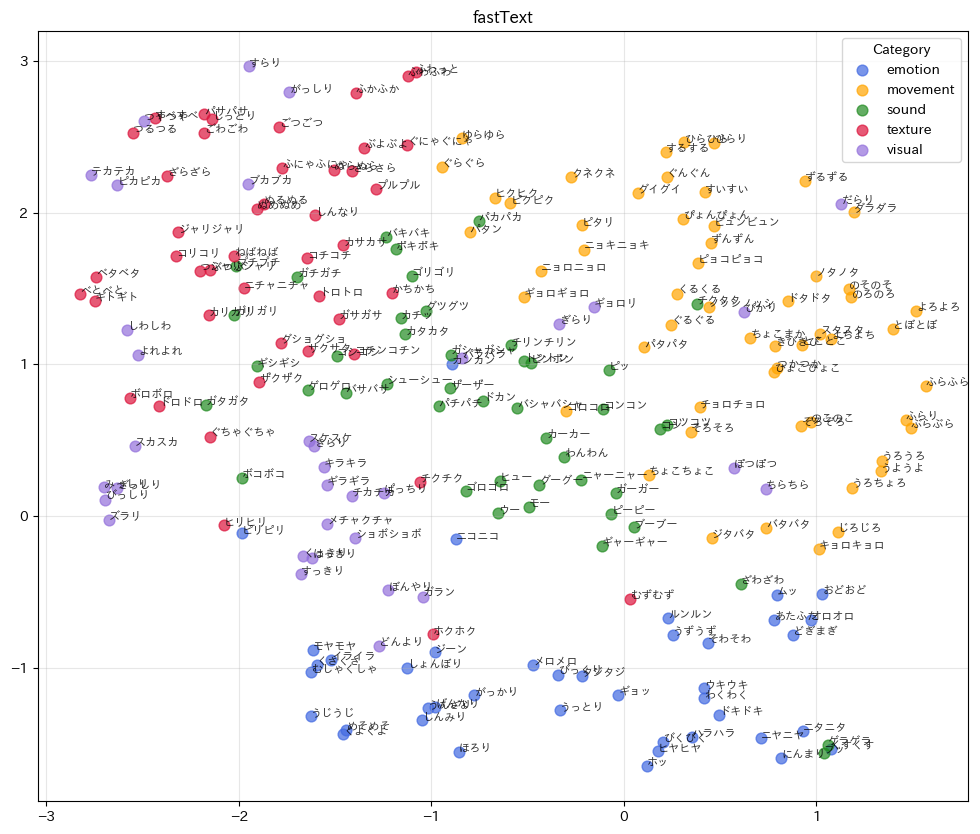

In [ ]:
def FastTextProcess(lrClf, svmClf, xFastText, yEncoded, labelEncoder):
    RunEvaluation(lrClf, svmClf, xFastText, yEncoded, labelEncoder, "fastText")

def Main():
    csvFile = CSV_FILE
    onomaDf = pd.read_csv(csvFile)

    labelEncoder = LabelEncoder()
    yEncoded = labelEncoder.fit_transform(onomaDf["category"])

    lrClf = LogisticRegression(max_iter=1000, random_state=42)
    svmClf = LinearSVC(max_iter=10000, random_state=42)

    fasttextModel = fasttext.load_model(fastTextModel)
    xFastText = np.array([fasttextModel.get_word_vector(w) for w in onomaDf["word"]])

    FastTextProcess(lrClf, svmClf, xFastText, yEncoded, labelEncoder)
    PlotUmap(
    xFastText, yEncoded, labelEncoder, onomaDf["word"].tolist(),
    "fastText", "umap_fasttext.png", colorMap
    )

if __name__ == "__main__":
    Main()

## Result of fastText:

| Category | Support | Logistic Regression (F1) | Linear SVM (F1) |
| :--- | :---: | :---: | :---: |
| **emotion** | 41 | 0.8941 | **0.8941** |
| **movement** | 55 | 0.8099 | **0.8571** |
| **sound** | 45 | 0.7470 | **0.7816** |
| **texture** | 45 | 0.8542 | **0.8842** |
| **visual** | 34 | 0.7273 | **0.7869** |
| **Overall Accuracy** | 220 | 0.8136 | **0.8455** |
| **Avg Macro-F1** | 220 | 0.8065  | **0.8408** |



# BERT
The pre-trained model `cl-tohoku/bert-base-japanese-v3` is used.

Extracting BERT Embeddings...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression (Mean Macro-F1): 0.7799


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


--- Detailed Classification Report: BERT (LR) ---
              precision    recall  f1-score   support

     emotion     0.8718    0.8293    0.8500        41
    movement     0.8000    0.8000    0.8000        55
       sound     0.8182    0.8000    0.8090        45
     texture     0.8000    0.8000    0.8000        45
      visual     0.6486    0.7059    0.6761        34

    accuracy                         0.7909       220
   macro avg     0.7877    0.7870    0.7870       220
weighted avg     0.7937    0.7909    0.7920       220

Linear SVM          (Mean Macro-F1): 0.7999

--- Detailed Classification Report: BERT (SVM) ---
              precision    recall  f1-score   support

     emotion     0.8947    0.8293    0.8608        41
    movement     0.8269    0.7818    0.8037        55
       sound     0.8605    0.8222    0.8409        45
     texture     0.7959    0.8667    0.8298        45
      visual     0.6579    0.7353    0.6944        34

    accuracy                         0

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


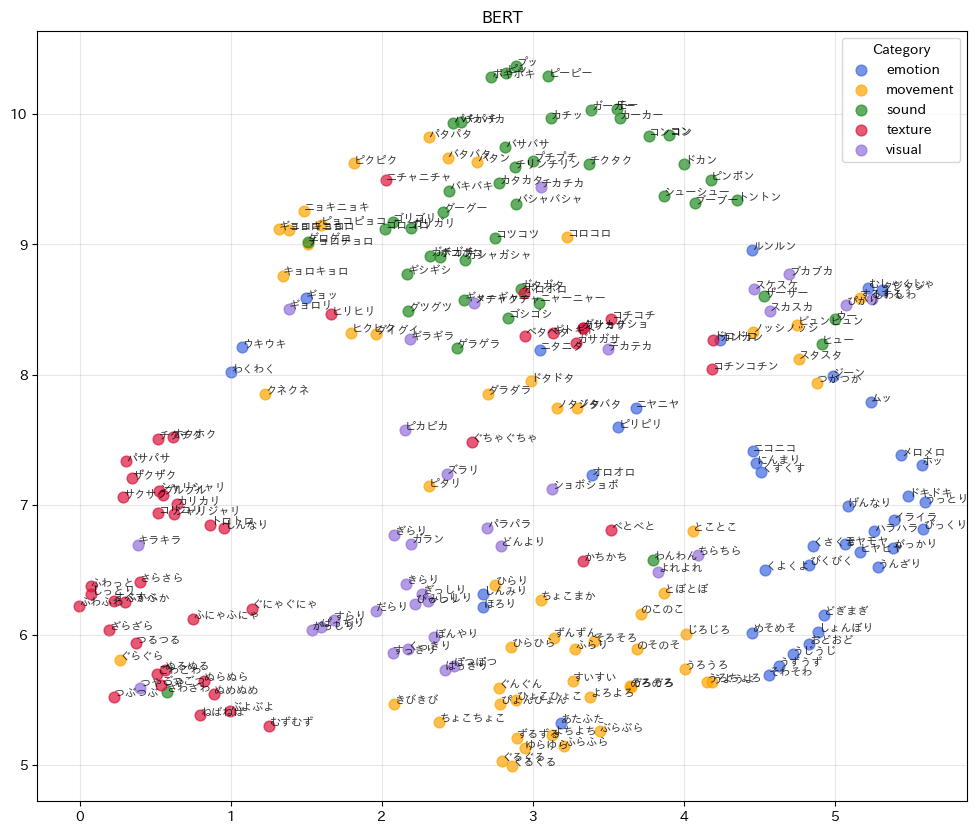

In [ ]:
modelName = "cl-tohoku/bert-base-japanese-v3"

def BertProcess(xBert, yEncoded, leBert):

    lrClf = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial')
    svmClf = LinearSVC(random_state=42, max_iter=10000)

    meanLr, meanSvm = RunEvaluation(
        lrClf,
        svmClf,
        xBert,
        yEncoded,
        leBert,
        "BERT"
    )

    return meanSvm, meanLr
def FindSublistIndex(targetList, mainList):
    """
    It uses a sliding window to return the first starting index in `mainList` that
    exactly matches `targetList`. It returns -1 if no match is found.
    """
    targetLen = len(targetList)
    if targetLen == 0 or targetLen > len(mainList):
        return -1
    for i in range(len(mainList) - targetLen + 1):
        if mainList[i : i + targetLen] == targetList:
          return i

    return -1
def ExtractAndPoolEmbeddings(startIndex, wordLen, lastHiddenState):
    """
    It extracts he tensor within the specified range based on the start index,
    applies average pooling, and returns a vector (NumPy array).
    If nothing is found (startIndex == -1), it falls back to the [CLS] token.
    """

    if startIndex != -1:
        targetEmbeddings = lastHiddenState[startIndex : startIndex + wordLen, :]
        pooledVector = torch.mean(targetEmbeddings, dim=0).numpy()
        return pooledVector, False
    return lastHiddenState[0, :].numpy(), True

def GetTargetWordVector(targetWord, bertTokenizer, tokenInputs, lastHiddenState):
    """
    It identifies a set of tokens for the target word using the sliding window method
    and returns an Average Pooling vector.
    """
    # Get the list of token IDs for the target word
    wordTokens = bertTokenizer.encode(targetWord, add_special_tokens=False)
    # List of token IDs for the entire text
    sentenceTokens = tokenInputs['input_ids'][0].tolist()

    startIndex = FindSublistIndex(wordTokens, sentenceTokens)
    return ExtractAndPoolEmbeddings(startIndex, len(wordTokens), lastHiddenState)

def ExtractBertContextSpace(csvFilePath):
    onomaDf = pd.read_csv(csvFilePath)
    onomaDf['category'] = onomaDf['category'].str.strip()

    bertTokenizer = BertJapaneseTokenizer.from_pretrained(modelName)
    bertModel = BertModel.from_pretrained(modelName)
    bertModel.eval()

    bertEmbeddings = []
    plotLabels = []
    onomaCategories = []

    stats = {cat: {'total': 0, 'fallback': 0, 'fragmented': 0, 'has_unk': 0}
            for cat in onomaDf['category'].unique()}

    with torch.no_grad():
        for index, row in onomaDf.iterrows():
            inputSentence = str(row['sentence'])
            targetWord = str(row['word'])
            category = row['category']

            tokenInputs = bertTokenizer(
                inputSentence, return_tensors="pt", truncation=True, max_length=128, padding=False
            )
            modelOutputs = bertModel(**tokenInputs)
            lastHiddenState = modelOutputs.last_hidden_state[0]

            wordVector, isFallback = GetTargetWordVector(
                targetWord, bertTokenizer, tokenInputs, lastHiddenState
            )

            stats[category]['total'] += 1
            wordTokens = bertTokenizer.encode(targetWord, add_special_tokens=False)
            decoded_tokens = bertTokenizer.convert_ids_to_tokens(wordTokens)

            if isFallback:
                stats[category]['fallback'] += 1

            # check [UNK] token
            if '[UNK]' in decoded_tokens:
                stats[category]['has_unk'] += 1

            # check fragmentation
            if len(wordTokens) >= 3:
                stats[category]['fragmented'] += 1
            # ----------------------------------------

            bertEmbeddings.append(wordVector)
            plotLabels.append(targetWord)
            onomaCategories.append(category)

    print("-" * 40)
    print("【BERT Tokenization Analysis per Category】")
    for cat, data in stats.items():
        total = data['total']
        if total == 0: continue
        fallback_rate = (data['fallback'] / total) * 100
        unk_rate = (data['has_unk'] / total) * 100
        frag_rate = (data['fragmented'] / total) * 100

        print(f"Category: {cat} (Total: {total})")
        print(f"  - Fallback to [CLS]: {data['fallback']} ({fallback_rate:.1f}%)")
        print(f"  - Contains [UNK]:    {data['has_unk']} ({unk_rate:.1f}%)")
        print(f"  - Fragmented (>=3):  {data['fragmented']} ({frag_rate:.1f}%)")
    print("-" * 40)

    xBert = np.array(bertEmbeddings)
    return xBert, plotLabels, onomaCategories



if __name__ == "__main__":
    print("Extracting BERT Embeddings...")
    xBert, plotLabels, categories = ExtractBertContextSpace(CSV_FILE)

    print("Running Classification...")
    leBert = LabelEncoder()
    yEncoded = leBert.fit_transform(categories)
    BertProcess(xBert, yEncoded, leBert)

    print("Generating UMAP Plot...")
    PlotUmap(
      xBert, yEncoded, leBert, plotLabels,
      "BERT", "umap_bert.png", colorMap
    )

##Result of BERT Classification Performance

### Tokenization

| Category | Total | Fallback to [CLS] | Contains [UNK] | Fragmented (≥3) |
| :--- | :---: | :---: | :---: | :---: |
| **Sound** | 45 | 0 (0.0%) | 0 (0.0%) | 30 (66.7%) |
| **Movement** | 55 | 1 (1.8%) | 0 (0.0%) | 46 (83.6%) |
| **Texture** | 45 | 0 (0.0%) | 0 (0.0%) | 37 (82.2%) |
| **Visual** | 34 | 2 (5.9%) | 0 (0.0%) | 22 (64.7%) |
| **Emotion** | 41 | 2 (4.9%) | 0 (0.0%) | 26 (63.4%) |  

### classification Performane

| Category | Support | Logistic Regression (F1) | Linear SVM (F1)
| :--- | :---: | :---: | :---: |
| **emotion** | 41 | 0.8500 | **0.8608** |
| **movement** | 55 | 0.8000 | **0.8037** |
| **sound** | 45 | 0.8090 | **0.8409** |
| **texture** | 45 | 0.8000 | **0.8298** |
| **visual** | 34 | 0.6761 | **0.6944** |
| **Overall Accuracy** | 220 | 0.7909 | **0.8091** |
| **Macro Avg F1** | 220 | 0.7870 | **0.8059** |

KANA_MAP is made according to Phonetic Symbol Chart for Syllables in Modern Japanese.

http://daijirin.dual-d.net/extra/nihongoon.html


In [ ]:
kanaMap = {
    'ア':'a', 'イ':'i', 'ウ':'u', 'エ':'e', 'オ':'o',
    'カ':'k a', 'キ':'k i', 'ク':'k u', 'ケ':'k e', 'コ':'k o',
    'サ':'s a', 'シ':'S i', 'ス':'s u', 'セ':'s e', 'ソ':'s o',
    'タ':'t a', 'チ':'tS i', 'ツ':'ts u', 'テ':'t e', 'ト':'t o',
    'ナ':'n a', 'ニ':'n i', 'ヌ':'n u', 'ネ':'n e', 'ノ':'n o',
    'ハ':'h a', 'ヒ':'h i', 'フ':'f u', 'ヘ':'h e', 'ホ':'h o',
    'マ':'m a', 'ミ':'m i', 'ム':'m u', 'メ':'m e', 'モ':'m o',
    'ヤ':'j a', 'ユ':'j u', 'ヨ':'j o',
    'ラ':'r a', 'リ':'r i', 'ル':'r u', 'レ':'r e', 'ロ':'r o',
    'ワ':'w a', 'ヲ':'o',
    'ガ':'g a', 'ギ':'g i', 'グ':'g u', 'ゲ':'g e', 'ゴ':'g o',
    'ザ':'z a', 'ジ':'dZ i', 'ズ':'z u', 'ゼ':'z e', 'ゾ':'z o',
    'ダ':'d a', 'ヂ':'dZ i', 'ヅ':'z u', 'デ':'d e', 'ド':'d o',
    'バ':'b a', 'ビ':'b i', 'ブ':'b u', 'ベ':'b e', 'ボ':'b o',
    'パ':'p a', 'ピ':'p i', 'プ':'p u', 'ペ':'p e', 'ポ':'p o',
    'キャ':'k j a', 'キュ':'k j u', 'キョ':'k j o',
    'シャ':'S j a', 'シュ':'S j u', 'ショ':'S j o',
    'チャ':'tS a', 'チュ':'tS u', 'チョ':'tS o',
    'ニャ':'n j a', 'ニュ':'n j u', 'ニョ':'n j o',
    'ヒャ':'h j a', 'ヒュ':'h j u', 'ヒョ':'h j o',
    'ミャ':'m j a', 'ミュ':'m j u', 'ミョ':'m j o',
    'リャ':'r j a', 'リュ':'r j u', 'リョ':'r j o',
    'ギャ':'g j a', 'ギュ':'g j u', 'ギョ':'g j o',
    'ジャ':'dZ a', 'ジュ':'dZ u', 'ジョ':'dZ o',
    'ビャ':'b j a', 'ビュ':'b j u', 'ビョ':'b j o',
    'ピャ':'p j a', 'ピュ':'p j u', 'ピョ':'p j o'
}

# Phoneme-based LSTM model
The model structure for Phoneme-based LSTM is Embedding plus Long Short-Term Memory(LSTM) Network. In this thesis, we construct Phoneme Model. Its model is composed of three layers: Embedding layer that converts input phoneme ID to continuous vectors, LSTM layer that maintains and updates time-series data, and fully connected layer(liner layer) for the next phoneme prediction. It is designed to keep the data about the phonemes entered at the beginning of the sequence, all the way to the end of the sequence without any reductions by LSTM's Cell state.


--- Training: LSTM Task A (Ono-only) ---
Epoch 10/50 | Loss: 1.0226
Epoch 20/50 | Loss: 0.9049
Epoch 30/50 | Loss: 0.7818
Epoch 40/50 | Loss: 1.1271
Epoch 50/50 | Loss: 0.7859

 EVALUATION: LSTM Task A (Ono-only) 


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression (Mean Macro-F1): 0.3033

--- Detailed Classification Report: LSTM Task A (Ono-only) (LR) ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

              precision    recall  f1-score   support

     emotion     0.2222    0.1463    0.1765        41
    movement     0.3871    0.4364    0.4103        55
       sound     0.3958    0.4222    0.4086        45
     texture     0.1818    0.1778    0.1798        45
      visual     0.3846    0.4412    0.4110        34

    accuracy                         0.3273       220
   macro avg     0.3143    0.3248    0.3172       220
weighted avg     0.3158    0.3273    0.3193       220

Linear SVM          (Mean Macro-F1): 0.2876

--- Detailed Classification Report: LSTM Task A (Ono-only) (SVM) ---
              precision    recall  f1-score   support

     emotion     0.2000    0.1707    0.1842        41
    movement     0.4107    0.4182    0.4144        55
       sound     0.3922    0.4444    0.4167        45
     texture     0.1429    0.1333    0.1379        45
      visual     0.3611    0.3824    0.3714        34

    accuracy                         0.3136       220
   macro avg     

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Logistic Regression (Mean Macro-F1): 0.2662

--- Detailed Classification Report: LSTM Task B (General) (LR) ---
              precision    recall  f1-score   support

     emotion     0.2121    0.1707    0.1892        41
    movement     0.5116    0.4000    0.4490        55
       sound     0.2727    0.2000    0.2308        45
     texture     0.3125    0.2222    0.2597        45
      visual     0.2025    0.4706    0.2832        34

    accuracy                         0.2909       220
   macro avg     0.3023    0.2927    0.2824       220
weighted avg     0.3184    0.2909    0.2916       220

Linear SVM          (Mean Macro-F1): 0.2787

--- Detailed Classification Report: LSTM Task B (General) (SVM) ---
              precision    recall  f1-score   support

     emotion     0.2500    0.3415    0.2887        41
    movement     0.5250    0.3818    0.4421        55
       sound     0.2500    0.1778    0.2078        45
     texture     0.3125    0.2222    0.2597        45
      visual   

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


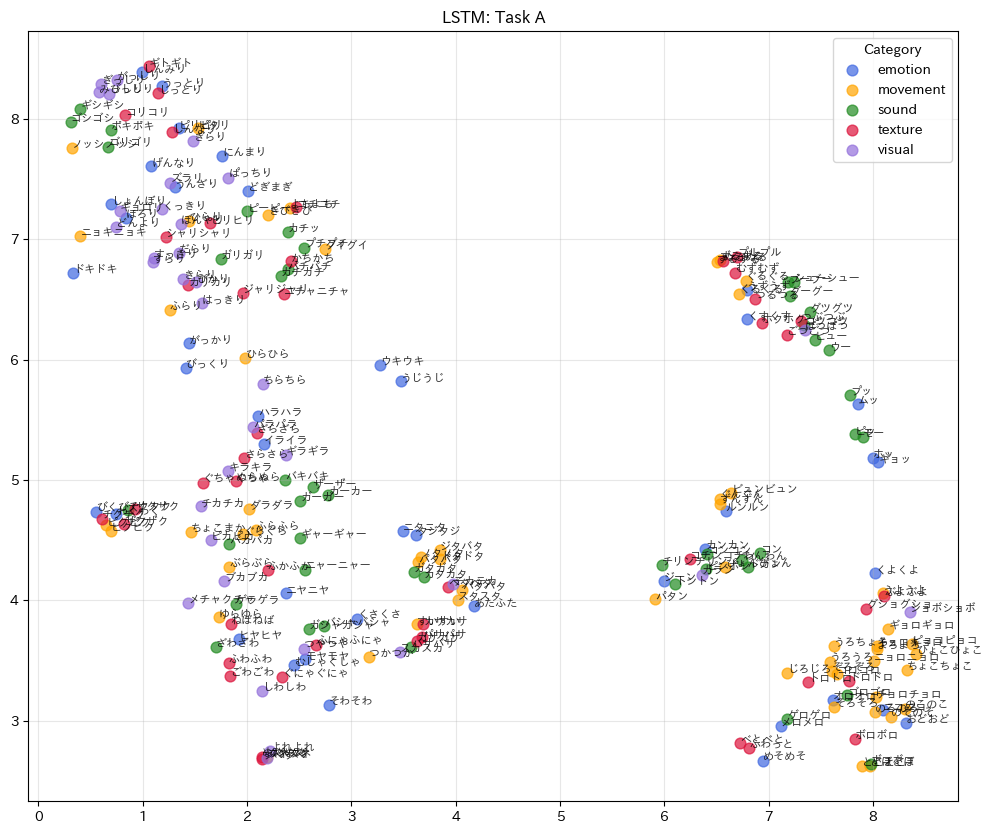

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


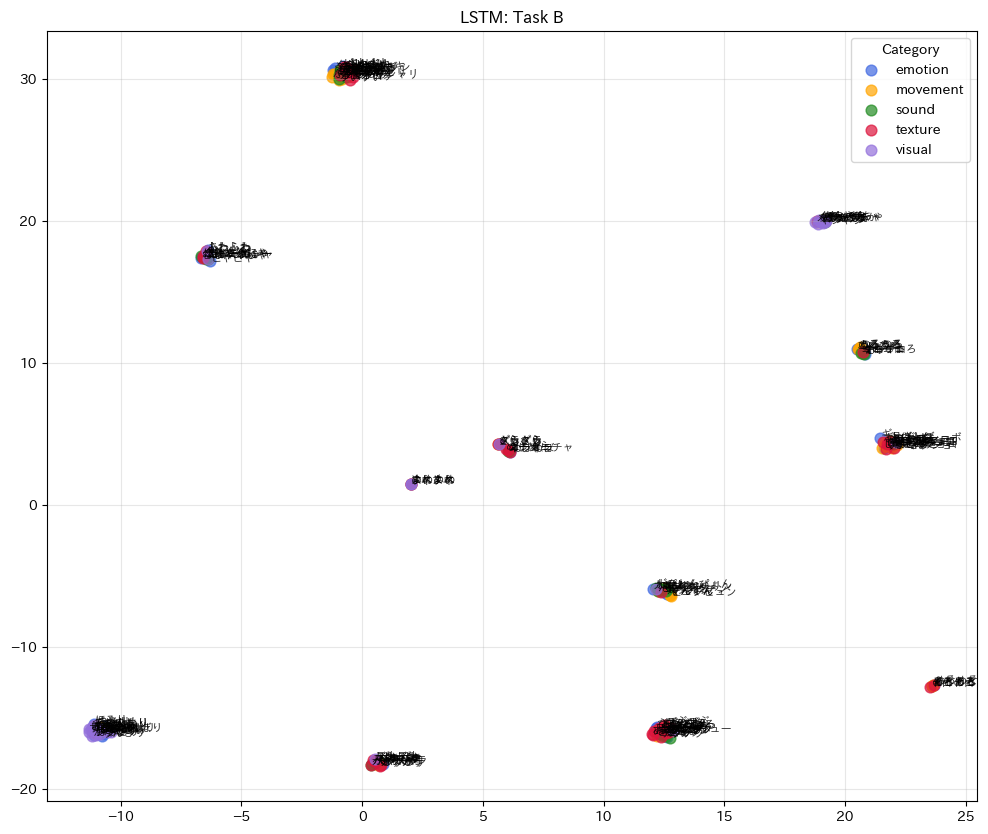


=== LSTM Task B: What is inside the clusters? ===

Cluster 0 (Size: 75 words):
ゴシゴシ, ざわざわ, ピッ, ピーピー, パチパチ, ポキポキ, プチプチ, カチッ, ギシギシ, バキバキ, ゴリゴリ, ガリガリ, ガチガチ, きびきび, グイグイ, ジタバタ, ノッシノッシ, ふらふら, スタスタ, よちよち, ゆらゆら, クネクネ, すいすい, ドタドタ, ふらり, ニョキニョキ, ひらり, ピタリ, かちかち, コチコチ, しっとり, シャリシャリ, ジャリジャリ, しんなり, すべすべ, ぬめぬめ, ふかふか, コリコリ, カリカリ, ヒリヒリ, ぴかり, きらり, ぼんやり, はっきり, くっきり, どんより, ぱっちり, ズラリ, ぎっしり, びっしり, みっしり, ぎらり, ギョロリ, がっしり, すっきり, すらり, スケスケ, だらり, よれよれ, ウキウキ, うじうじ, げんなり, しょんぼり, しんみり, そわそわ, タジタジ, ドキドキ, どぎまぎ, びっくり, がっかり, うっとり, うんざり, ほろり, にんまり, ピリピリ

Cluster 1 (Size: 31 words):
グーグー, ウー, チクタク, ブーブー, プッ, グツグツ, シューシュー, コツコツ, ヒュー, ぐるぐる, くるくる, ずるずる, ピクピク, ヒクヒク, するする, ごつごつ, サクサク, ザクザク, つるつる, ぬるぬる, つぶつぶ, プルプル, チクチク, むずむず, ホクホク, ぽつぽつ, びくびく, わくわく, ムッ, うずうず, くすくす

Cluster 2 (Size: 4 words):
チリンチリン, ピンポン, ぴょんぴょん, ジーン

Cluster 3 (Size: 41 words):
ゲロゲロ, モー, ゴロゴロ, ボコボコ, うろうろ, キョロキョロ, コロコロ, ぞろぞろ, ちょこちょこ, とことこ, とぼとぼ, ニョロニョロ, のそのそ, のこのこ, のろのろ, ひょこひょこ, ピョコピョコ, うろちょろ, チョロチョロ, うようよ, よろよろ, そろそろ, じろじろ, ギョロギョロ, ギトギト, グショグショ, トロトロ, べとべと, 

In [ ]:
largeDictFile = "data/large_japanese_words.txt"

class PhonemeProcessor:
    """A class that handles the normalization and phonemic conversion of Japanese text"""

    def __init__(self, kanaMap: Dict[str, str]):
        self.kanaMap = kanaMap

    def GetNasalAssimilation(self, nextPhonemes):
        if not nextPhonemes: return 'N'

        firstPhoneme = nextPhonemes[0]
        if firstPhoneme in {'b', 'p', 'm'}: return 'm'
        if firstPhoneme in {'k', 'g'}: return 'N'

        return 'n'

    def GetNextKanaKey(self, kata: str, currentIndex: int) -> Optional[str]:
        """
        It etrieves the next kana character (either a single character or a two-character combination, such as a palatalized sound)
        """
        if currentIndex + 1 >= len(kata):
            return None

        # Check if the next two characters are in the dictionary (anticipating palatalized consonants)
        if currentIndex + 2 <= len(kata) and kata[currentIndex+1:currentIndex+3] in self.kanaMap:
            return kata[currentIndex+1:currentIndex+3]

        # If not, the next character
        return kata[currentIndex+1]

    def ConvertToPhonemes(self, word: str) -> List[str]:
        kata = jaconv.hira2kata(str(word))
        phonemes = []
        lastVowel = 'a'
        i = 0

        while i < len(kata):
            # 1. Palatalized consonants (2-character processing)
            if i + 1 < len(kata) and kata[i:i+2] in self.kanaMap:
                chars = self.kanaMap[kata[i:i+2]].split()
                phonemes.extend(chars)
                lastVowel = chars[-1]
                i += 2
                continue

            # The following section processes one character at a time
            char = kata[i]
            nextKey = self.GetNextKanaKey(kata, i)

            # 2. geminate consonant (ッ)
            if char == 'ッ':
                if nextKey and nextKey in self.kanaMap:
                    phonemes.append(self.kanaMap[nextKey].split()[0])

            # 3. Long vowel (ー)
            elif char == 'ー':
                phonemes.append(lastVowel)

            # 4. Plosive (ン)
            elif char == 'ン':
                nextPh = self.kanaMap.get(nextKey, "").split() if nextKey else None
                phonemes.append(self.GetNasalAssimilation(nextPh))

            # 5. Standard kana
            elif char in self.kanaMap:
                chars = self.kanaMap[char].split()
                phonemes.extend(chars)
                lastVowel = chars[-1]

            i += 1

        return phonemes

class PhonemeLM(nn.Module):
    def __init__(self, vocabSize, embedDim = 32, hiddenDim = 64):
        super().__init__()
        # It takes a raw phoneme ID and converts it into a dense, 32-dimensional continuous vector
        self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=0) # padding_idx=0 tells the model to completely ignore padding tokens
        # It takes the 32D embeddings and processes them step-by-step.
        # As it reads each phoneme, it updates its 64-dimensional internal memory
        self.lstm = nn.LSTM(embedDim, hiddenDim, batch_first=True)
        # It takes the 64D output from the LSTM and projects it back up to the size of your entire vocabulary.
        # This is used to calculate the probability of what the next phoneme will be.
        self.fc = nn.Linear(hiddenDim, vocabSize)

    def forward(self, xTensor):
        # The input tensor of phoneme IDs is converted into their vector representations.
        xEmbed = self.embedding(xTensor)

        # The embeddings are fed into the LSTM.
        # output contains the hidden states for every single time step in the sequence.
        # hn contains the final hidden state of the LSTM after reading the whole sequence.
        output, (hn, _) = self.lstm(xEmbed)

        # self.fc(output is the raw prediction scores (logits) for the next phoneme.
        # This is what we use to train the model using Cross-Entropy Loss.
        # hn[-1] extracts he absolute final hidden state of the top layer of the LSTM.
        # Because the LSTM processes sequentially,
        # this single 64-dimensional vector contains the accumulated "memory" of the entire phoneme sequence.
        # This is the exact vector we are extracting and feeding into our SVM classifier.
        return self.fc(output), hn[-1]

class EmbeddingEngine:
    """
    A class that manages learning and the extraction of embedding vectors
    """
    def __init__(self, processor, config):
        self.processor = processor
        self.config = config
        # <PAD> (0): Padding (used to make sequences the same length if needed).
        # <SOS> (1): Start of Sequence (tells the model a new word is beginning).
        # <EOS> (2): End of Sequence (tells the model the word is finished).
        self.vocab = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2}
        self.model = None

    def BuildVocab(self, corpus):
        for phonemeList in corpus:
            for phoneme in phonemeList:
                if phoneme not in self.vocab:
                    self.vocab[phoneme] = len(self.vocab) # it assigns it a new, unique integer ID

    def FitModel(self, words, epochs = 50):
        # It converts all your text words into phoneme lists and builds the vocabulary.
        phonemeCorpus = [self.processor.ConvertToPhonemes(word) for word in words]
        self.BuildVocab(phonemeCorpus)
        self.model = PhonemeLM(len(self.vocab))
        optimizer = optim.Adam(self.model.parameters(), lr=0.01)
        criterion = nn.CrossEntropyLoss(ignore_index=0)

        self.model.train()
        for epoch in range(epochs):
            totalLoss = 0 # a penalty counter
            for phonemeList in phonemeCorpus:
                if not phonemeList: continue

                # Converts sounds to numbers
                indices = [self.vocab[phoneme] for phoneme in phonemeList]
                # xTensor is what the model sees. It always starts with <SOS>.
                xTensor = torch.tensor([[self.vocab['<SOS>']] + indices], dtype=torch.long)
                # yTensor is what the model should predict. It ends with <EOS>.
                yTensor = torch.tensor([indices + [self.vocab['<EOS>']]], dtype=torch.long)

                # we clear out the leftover gradients from the previous word to avoid mix together.
                optimizer.zero_grad()
                # make a guess(forward pass)
                logits, _ = self.model(xTensor)

                # grade the guess(calcuate loss).
                # The criterion compares the model's predictions (logits) against the actual correct answers (yTensor).
                loss = criterion(logits.transpose(1, 2), yTensor)
                # Figure out what went wrong (Backpropagation).
                loss.backward()
                # Then, update the brain. It changes the model's weights based on the calculations from loss.backward().
                optimizer.step()
                totalLoss += loss.item()

            if (epoch + 1) % 10 == 0: # log
                print(f"Epoch {epoch+1}/{epochs} | Loss: {totalLoss/len(phonemeCorpus):.4f}")

    def TransformWords(self, words):
        self.model.eval() # This switches the model from "Training Mode" to "Evaluation Mode"
        embeddings = []
        with torch.no_grad(): # his tells PyTorch to completely turn off the calculus engine that tracks gradients.
            for word in words:
                phonemeList = self.processor.ConvertToPhonemes(word)
                if not phonemeList:
                    embeddings.append(np.zeros(self.model.lstm.hidden_size))
                    continue
                # It translates the letters into numbers.
                xTensor = torch.tensor([[self.vocab['<SOS>']] + [self.vocab.get(phoneme, 0) for phoneme in phonemeList]])
                # hn is the final hidden state.
                _, hn = self.model(xTensor)
                embeddings.append(hn.squeeze().numpy())
        return np.array(embeddings)

def EvaluateEmbeddings(xFeatures, yEncoded, labelEncoder, taskName):
    lrClf = LogisticRegression(random_state=42, max_iter=1000, multi_class='multinomial')
    svmClf = LinearSVC(random_state=42, max_iter=10000)

    meanLr, meanSvm = RunEvaluation(
        lrClf,
        svmClf,
        xFeatures,
        yEncoded,
        labelEncoder,
        taskName
    )

    return meanSvm, meanLr

def AnalyzeLstmClusters(embeddings, words, n_clusters=8):
    """
    Groups words based on their embedding proximity to see what the LSTM actually learned.
    """
    # 1. We cluster the raw embeddings (or you could cluster the UMAP output)
    # Using KMeans for simplicity to find the distinct "blobs" you see in the plot
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(embeddings)

    # 2. Put the results in a DataFrame to easily view them
    df_clusters = pd.DataFrame({
        'Word': words,
        'Cluster': cluster_labels
    })

    # 3. Print the words in each cluster
    print(f"\n=== LSTM Task B: What is inside the clusters? ===")
    for c in range(n_clusters):
        words_in_cluster = df_clusters[df_clusters['Cluster'] == c]['Word'].tolist()
        print(f"\nCluster {c} (Size: {len(words_in_cluster)} words):")
        print(", ".join(words_in_cluster))

def RunLstmTask(trainWords, targetWords, epochs, taskName, processor, yEncoded, labelEncoder):
    print(f"\n--- Training: {taskName} ---")
    engine = EmbeddingEngine(processor, {})
    engine.FitModel(trainWords, epochs=epochs)

    embeddings = engine.TransformWords(targetWords)
    EvaluateEmbeddings(embeddings, yEncoded, labelEncoder, taskName)

    return embeddings

def Main():
    onomaDf = pd.read_csv(CSV_FILE)
    onomaDf['category'] = onomaDf['category'].str.strip()

    onoWords = onomaDf['word'].tolist()
    onomaCategories = onomaDf['category'].tolist()

    labelEncoder = LabelEncoder()
    yEncoded = labelEncoder.fit_transform(onomaCategories)

    try:
        processor = PhonemeProcessor(kanaMap=kanaMap)
    except NameError:
        sys.exit(1)

    if os.path.exists(largeDictFile):
        with open(largeDictFile, 'r', encoding='utf-8') as f:
            largeCorpus = [line.strip() for line in f if line.strip()]
    else:
        print(f"{largeDictFile} not found. Using a small fallback corpus.")
        sys.exit(1)

    # Task A
    embedsA = RunLstmTask(
        trainWords=onoWords,          # The training data consists solely of onomatopoeia
        targetWords=onoWords,         # The extraction targets are also onomatopoeia
        epochs=50,
        taskName="LSTM Task A (Ono-only)",
        processor=processor,
        yEncoded=yEncoded,
        labelEncoder=labelEncoder
    )

    # Task B
    combinedCorpus = list(set(onoWords + largeCorpus))

    embedsB = RunLstmTask(
        trainWords=combinedCorpus,    # The training data includes general vocabulary
        targetWords=onoWords,         # The extraction targets are onomatopoeia
        epochs=30,
        taskName="LSTM Task B (General)",
        processor=processor,
        yEncoded=yEncoded,
        labelEncoder=labelEncoder
    )

    PlotUmap(
        embedsA, yEncoded, labelEncoder, onoWords,
        "LSTM: Task A", "umap_lstm_taskA.png", colorMap
    )

    PlotUmap(
        embedsB, yEncoded, labelEncoder, onoWords,
        "LSTM: Task B", "umap_lstm_taskB.png", colorMap
    )

    AnalyzeLstmClusters(embedsB, onoWords, n_clusters=8)
if __name__ == "__main__":
    Main()

## Result of LSTM task A

| Category | Support | Logistic Regression (F1) | Linear SVM (F1) |
| :--- | :---: | :---: | :---: |
| **emotion** | 41 | 0.1765 | **0.1842** |
| **movement** | 55 | 0.4103 | **0.4144** |
| **sound** | 45 | 0.4086 | **0.4167** |
| **texture** | 45 | **0.1798** | 0.1379 |
| **visual** | 34 | **0.4110** | 0.3714 |
| **Overall Accuracy** | 220 | **0.3273** | 0.3136 |
| **Avg Macro-F1** | 220 | **0.3172** | 0.3049 |

## Result of LSTM task B

| Category | Support | Logistic Regression (F1) | Linear SVM (F1) |
| :--- | :---: | :---: | :---: |
| **emotion** | 41 | 0.1892 | **0.2887** |
| **movement** | 55 | **0.4490** | 0.4421 |
| **sound** | 45 | **0.2308** | 0.2078 |
| **texture** | 45 | **0.2597** | **0.2597** |
| **visual** | 34 | **0.2832** | 0.2128 |
| **Overall Accuracy** | 220 | **0.2909** | 0.2864 |
| **Avg Macro-F1** | 220 | **0.2824** | 0.2822 |